In [73]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [74]:
# Import scikit-learn libraries

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings("ignore")

In [75]:
# Loading the dataset

df = pd.read_csv('AmesHousing.csv')

In [76]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [77]:
df.shape

(2930, 82)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [79]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [80]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [81]:
# Dropping 'Order' and 'PID' coloumns

df.drop(columns=['Order','PID'], axis=1)

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


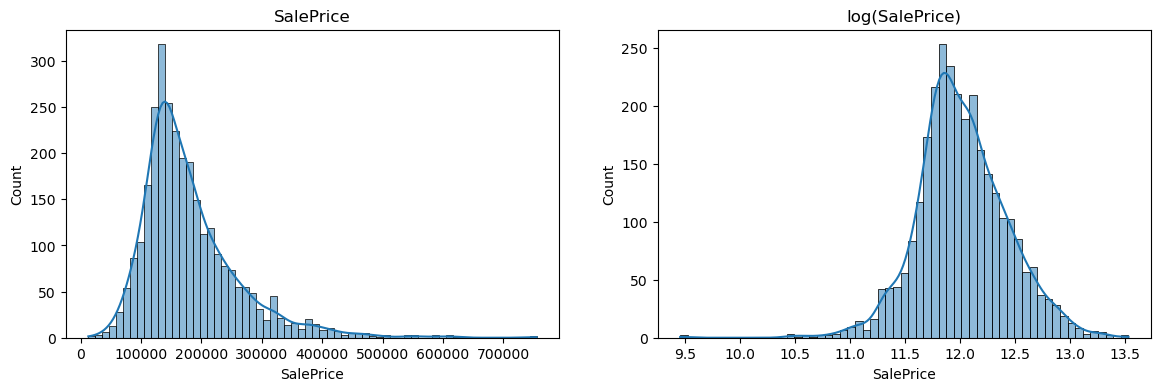

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")

sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log(SalePrice)")
plt.show()

In [83]:
# Investigating missing values

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

In [84]:
# The main reason why values is missing is bcs its not present, replacing it with 'None'

none_means_absent = [
    "Alley", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1",
    "BsmtFin Type 2", "Fireplace Qu", "Garage Type", "Garage Finish",
    "Garage Qual", "Garage Cond", "Pool QC", "Fence", "Misc Feature",
    "Mas Vnr Type"
]

for col in none_means_absent:
    df[col] = df[col].fillna("None")

In [85]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [86]:
corr = df.select_dtypes(include=np.number).corr()["SalePrice"].sort_values(ascending=False)
print(corr.head(11))

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640381
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Name: SalePrice, dtype: float64


### Feature Engineering

In [87]:
# Total square footage (basement + 1st + 2nd floor)
df["Total_SF"] = df["Total Bsmt SF"] + df["1st Flr SF"] + df["2nd Flr SF"]

# Total bathrooms (half baths count as 0.5)
df["Total_Bath"] = (df["Full Bath"] + 0.5 * df["Half Bath"]
                    + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"])

# Age of house at time of sale, and years since remodel
df["House_Age"] = df["Yr Sold"] - df["Year Built"]
df["Since_Remod"] = df["Yr Sold"] - df["Year Remod/Add"]

# Total porch area
df["Total_Porch_SF"] = (df["Open Porch SF"] + df["Enclosed Porch"]
                        + df["3Ssn Porch"] + df["Screen Porch"] + df["Wood Deck SF"])

# Simple flags
df["Has_Pool"]    = (df["Pool Area"] > 0).astype(int)
df["Has_Garage"]  = (df["Garage Area"] > 0).astype(int)
df["Has_Fireplace"] = (df["Fireplaces"] > 0).astype(int)


In [88]:
df["House_Age"]   = df["House_Age"].clip(lower=0)
df["Since_Remod"] = df["Since_Remod"].clip(lower=0)
print("Negative ages remaining:", ((df["House_Age"] < 0) | (df["Since_Remod"] < 0)).sum())

Negative ages remaining: 0


In [89]:
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

qual_cols = ["Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
             "Heating QC", "Kitchen Qual", "Fireplace Qu",
             "Garage Qual", "Garage Cond", "Pool QC"]

for col in qual_cols:
    df[col] = df[col].map(quality_map).fillna(0).astype(int)

print("Ordinal columns encoded.")
df[qual_cols].head()

Ordinal columns encoded.


,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Heating QC,Kitchen Qual,Fireplace Qu,Garage Qual,Garage Cond,Pool QC
0,3,3,3,4,2,3,4,3,3,0
1,3,3,3,3,3,3,0,3,3,0
2,3,3,3,3,3,4,0,3,3,0
3,4,3,3,3,5,5,3,3,3,0
4,3,3,4,3,4,3,3,3,3,0


In [90]:
# Keep neighborhood label aside for the clustering section
df["Neighborhood_label"] = df["Neighborhood"]

# Exclude the label so it doesn't get one-hot encoded
cat_cols = [c for c in df.select_dtypes(include="object").columns
            if c != "Neighborhood_label"]
print("Categorical columns to encode:", len(cat_cols))

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
print("Neighborhood_label present:", "Neighborhood_label" in df_encoded.columns)

Categorical columns to encode: 33
Shape after encoding: (2930, 253)
Neighborhood_label present: True


In [91]:
X = df_encoded.drop(columns=["SalePrice", "Neighborhood_label"])
y = np.log1p(df_encoded["SalePrice"])   

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (2930, 251)
Target: (2930,)


In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [96]:
def evaluate(model, X_tr, X_te, name="Model"):
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)

    r2 = r2_score(y_test, pred)

    pred_clipped = np.clip(pred, 0, 14)   
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_clipped)))
    mae  = mean_absolute_error(np.expm1(y_test), np.expm1(pred_clipped))

    print(f"{name}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : ${rmse:,.0f}")
    print(f"  MAE  : ${mae:,.0f}\n")
    return model

In [97]:
lin_reg = LinearRegression()
lin_reg = evaluate(lin_reg, X_train_scaled, X_test_scaled, "Linear Regression")

Linear Regression
  R²   : -4604833791456908.0000
  RMSE : $63,325
  MAE  : $17,455



In [98]:
top_feats = ["Overall Qual", "Total_SF", "Gr Liv Area", "Garage Cars", "Total_Bath"]

X_train_top = X_train[top_feats]
X_test_top  = X_test[top_feats]

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("reg", LinearRegression())
])

poly_model = evaluate(poly_model, X_train_top, X_test_top, "Polynomial Regression (deg 2, top features)")

Polynomial Regression (deg 2, top features)
  R²   : 0.8791
  RMSE : $31,709
  MAE  : $19,527



In [99]:
linear_top = Pipeline([
    ("scale", StandardScaler()),
    ("reg", LinearRegression())
])
linear_top = evaluate(linear_top, X_train_top, X_test_top, "Linear (top features only)")

Linear (top features only)
  R²   : 0.8573
  RMSE : $39,625
  MAE  : $21,633



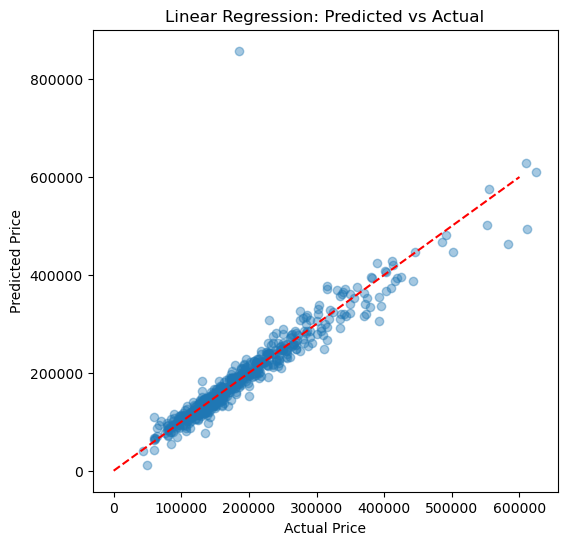

In [100]:
pred = lin_reg.predict(X_test_scaled)
plt.figure(figsize=(6, 6))
plt.scatter(np.expm1(y_test), np.expm1(pred), alpha=0.4)
plt.plot([0, 600000], [0, 600000], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

In [102]:
from sklearn.linear_model import RidgeCV, LassoCV

In [103]:
alphas = [0.01, 0.1, 1, 5, 10, 20, 50, 100]

ridge = RidgeCV(alphas=alphas, cv=5)
ridge = evaluate(ridge, X_train_scaled, X_test_scaled, "Ridge Regression")
print("Best alpha:", ridge.alpha_)

Ridge Regression
  R²   : 0.9130
  RMSE : $31,750
  MAE  : $15,389

Best alpha: 100.0


In [104]:
lasso = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)
lasso = evaluate(lasso, X_train_scaled, X_test_scaled, "Lasso Regression")
print("Best alpha:", lasso.alpha_)

Lasso Regression
  R²   : 0.9156
  RMSE : $32,890
  MAE  : $15,883

Best alpha: 0.0032812970821313858


In [105]:
coef = pd.Series(lasso.coef_, index=X_train.columns)
print("Total features      :", len(coef))
print("Features kept        :", (coef != 0).sum())
print("Features dropped (=0):", (coef == 0).sum())

Total features      : 251
Features kept        : 95
Features dropped (=0): 156


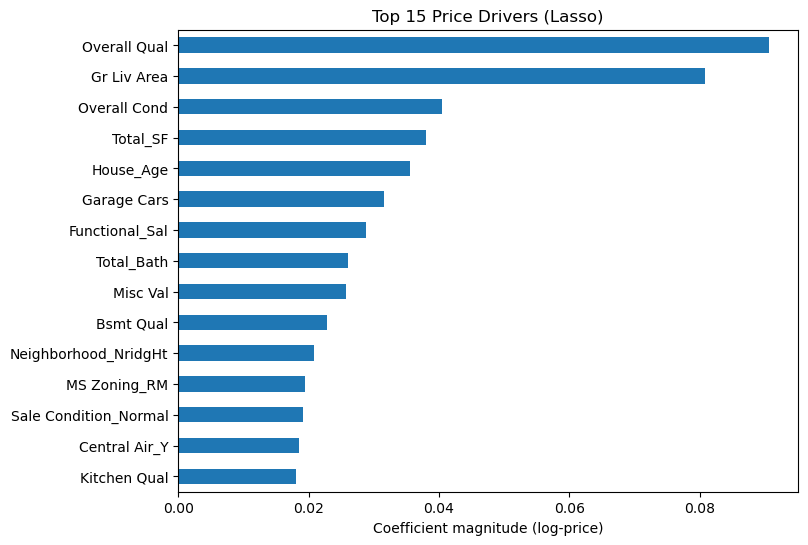

Overall Qual             0.090586
Gr Liv Area              0.080800
Overall Cond             0.040400
Total_SF                 0.037957
House_Age                0.035555
Garage Cars              0.031509
Functional_Sal           0.028734
Total_Bath               0.026018
Misc Val                 0.025781
Bsmt Qual                0.022843
Neighborhood_NridgHt     0.020774
MS Zoning_RM             0.019481
Sale Condition_Normal    0.019130
Central Air_Y            0.018508
Kitchen Qual             0.018061
dtype: float64

In [106]:
top = coef[coef != 0].abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top.sort_values().plot(kind="barh")
plt.title("Top 15 Price Drivers (Lasso)")
plt.xlabel("Coefficient magnitude (log-price)")
plt.show()

coef[coef != 0].abs().sort_values(ascending=False).head(15)

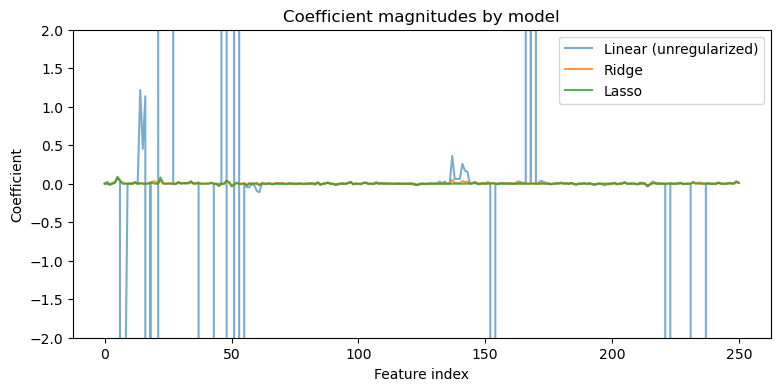

In [107]:
lin_full = LinearRegression().fit(X_train_scaled, y_train)

plt.figure(figsize=(9, 4))
plt.plot(lin_full.coef_,  label="Linear (unregularized)", alpha=0.6)
plt.plot(ridge.coef_, label="Ridge", alpha=0.8)
plt.plot(lasso.coef_, label="Lasso", alpha=0.8)
plt.ylim(-2, 2)   # zoom in; baseline has spikes far outside this
plt.legend()
plt.title("Coefficient magnitudes by model")
plt.xlabel("Feature index"); plt.ylabel("Coefficient")
plt.show()

In [108]:
from sklearn.metrics import silhouette_score

In [109]:
cluster_feats = [
    "Total_SF", "Gr Liv Area", "Overall Qual", "Overall Cond",
    "House_Age", "Total_Bath", "Bedroom AbvGr", "Garage Cars",
    "TotRms AbvGrd", "Lot Area", "Fireplaces", "Total_Porch_SF"
]

X_cluster = df[cluster_feats].copy()

In [110]:
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

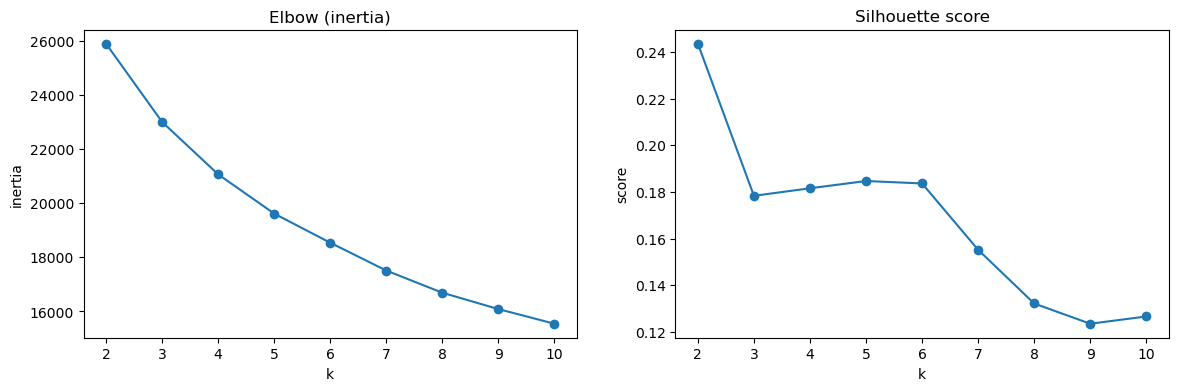

In [111]:
inertia, sil = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertia, "o-"); axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(K_range, sil, "o-"); axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("score")
plt.show()

In [112]:
k = 4   # adjust based on the plots
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    994
1    464
2    914
3    558
Name: count, dtype: int64


In [113]:
profile = df.groupby("Cluster")[cluster_feats].mean().round(1)
profile["Avg_Price"] = df.groupby("Cluster")["SalePrice"].mean().round(0)
profile["Count"] = df["Cluster"].value_counts().sort_index()
profile.T 

Cluster,0,1,2,3
Total_SF,1850.9,3727.2,2646.2,2641.2
Gr Liv Area,1050.0,2267.4,1491.3,1676.1
Overall Qual,5.0,7.7,6.8,5.5
Overall Cond,5.9,5.3,5.1,5.9
House_Age,54.6,15.6,11.2,62.6
Total_Bath,1.5,3.1,2.6,2.0
Bedroom AbvGr,2.5,3.4,2.6,3.5
Garage Cars,1.2,2.6,2.1,1.5
TotRms AbvGrd,5.3,8.4,6.2,7.4
Lot Area,8186.2,15549.4,9013.1,11009.8


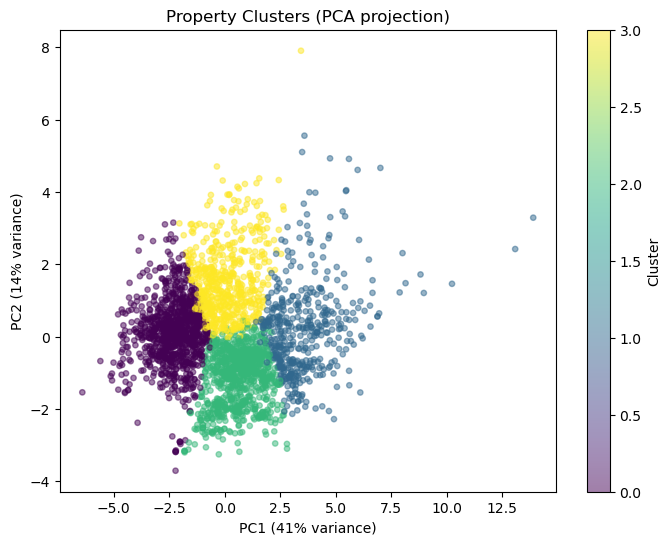

In [114]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"],
                      cmap="viridis", alpha=0.5, s=15)
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
plt.title("Property Clusters (PCA projection)")
plt.show()

In [115]:
crosstab = pd.crosstab(df["Neighborhood_label"], df["Cluster"])
# Show which cluster dominates each neighborhood
dominant = crosstab.idxmax(axis=1).sort_values()
print("Dominant cluster per neighborhood:\n")
print(dominant)

Dominant cluster per neighborhood:

Neighborhood_label
MeadowV    0
Blueste    0
BrDale     0
BrkSide    0
Mitchel    0
OldTown    0
Edwards    0
NAmes      0
Sawyer     0
GrnHill    0
IDOTRR     0
NridgHt    1
NoRidge    1
ClearCr    1
StoneBr    2
Somerst    2
SawyerW    2
Blmngtn    2
NPkVill    2
Timber     2
Landmrk    2
Greens     2
Gilbert    2
CollgCr    2
NWAmes     2
Veenker    2
SWISU      3
Crawfor    3
dtype: int32
